# Project 2 - Hospital Utilization

We are simulating a hospital with 3 wards each with it's own type of patient and felszereltség. <br>
Arrival times are a Poisson process. <br>
LOS times are assumed to be log-normal but it's often simulated as exponential. <br>

The hospital was forced to create these two new wards (A and B) to deal with a pandemic. <br>
If Patient -> Ward B but Ward B is full -> Ward A <br>
If Patient -> Ward A but Ward A is full -> Different hospital <br>
If Patient -> Ward C but Ward C is full -> Different hospital <br>

Beds and staff are allocated from the ones that Ward C originally had.

**Ward A: Regular care** 

Arrival rate: $λ_1(t) = −(1/3650)t^2 + (1/10)t$ patients per day, where $0 ≤ t ≤ 365$ <br>
Lenght-of-stay: $Lognormal(µ, σ^2)$ with $µ = log(4√2)$ and $σ^2 = log(2)$, <br>
corresponding to a mean and standard deviation of 8 days

**Ward B: Intensive care**

Arrival rate: $λ_2(t) = \frac{1}{5}λ_1(t)$ patients per day <br>
Length-of-stay: $Lognormal(µ, σ^2)$ with $µ = log(6√2)$ and $σ^2 = log(2)$, <br>
corresponding to a meanand standard deviation of 12 days

**Ward C: Other**

Arrival rate: $λ_3 = 6$ patients per day. <br>
Length-of-stay: $Lognormal(µ, σ^2)$ with $µ = log(5√2)$ and $σ^2 = log(2)$, <br>
corresponding to a meanand standard deviation of 10 days. <br>
Moreover, Ward C contained 75 beds, but some of these are now moved to Ward A and B

In [1]:

# Install compatible versions together so pip resolves them correctly
#import subprocess, sys
#subprocess.run([sys.executable, '-m', 'pip', 'install',
#    'numpy>=2.0,<2.6', 'scipy>=1.14', 'matplotlib>=3.9',
#    '--upgrade', '--quiet'], check=False)

import numpy as np
import matplotlib.pyplot as plt
import scipy
print(f"numpy {np.__version__}, scipy {scipy.__version__}, matplotlib {__import__('matplotlib').__version__}")

def sample_LOS(patient_type, num_samples):
    
    if patient_type == 'A':
        mu = np.log(4 * np.sqrt(2))
        sigma = np.sqrt(np.log(2))
    elif patient_type == 'B':
        mu = np.log(6 * np.sqrt(2))
        sigma = np.sqrt(np.log(2))
    elif patient_type == 'C':
        mu = np.log(5 * np.sqrt(2))
        sigma = np.sqrt(np.log(2))
    else:
        raise ValueError("Invalid patient type. Choose 'A', 'B', or 'C'.")
    
    return np.random.lognormal(mean=mu, sigma=sigma, size=num_samples)

def sample_arrivals(patient_type, t):

    if patient_type == 'A':
        arrival_rate = -(1/3650) * t**2 + (1/10) * t
    elif patient_type == 'B':
        arrival_rate = (1/5) * (-(1/3650) * t**2 + (1/10) * t)
    elif patient_type == 'C':
        arrival_rate = 6
    else:
        raise ValueError("Invalid patient type. Choose 'A', 'B', or 'C'.")
    
    return np.random.poisson(arrival_rate)

def sample_arrivals(exponential = False):
    # sample_arrivals on a continuous time scale, using thinning algorithm
    # Define the maximum arrival rate for each patient type
    arrival_rates = {
        'A': lambda t: -(1/3650) * t**2 + (1/10) * t,
        'B': lambda t: (1/5) * (-(1/3650) * t**2 + (1/10) * t),
        'C': lambda t: 6
    }
    max_arrival_rates = {
        'A': np.max([-(1/3650) * t**2 + (1/10) * t for t in range(0, 365)]),  
        'B': np.max([(1/5) * (-(1/3650) * t**2 + (1/10) * t) for t in range(0, 365)]),  
        'C': 6.0
    }
    # simulate arrivals for each patient type
    type_to_code = {'A': 0, 'B': 1, 'C': 2}  # optional decode: {0:'A', 1:'B', 2:'C'}
    times_parts = []
    types_parts = []
    times_LOS = []

    for patient_type in ('A', 'B', 'C'):
        if exponential:
            # Homogeneous Poisson process approximation using max rate
            arrival_times = [0.0]
            while arrival_times[-1] < 365:
                inter = np.random.exponential(1.0 / max_arrival_rates[patient_type], size=1000)
                arrival_times = np.cumsum(inter)
            times = arrival_times[arrival_times < 365]
        else:
            # Thinning for NHPP
            n = np.random.poisson(max_arrival_rates[patient_type] * 365)
            proposal_times = np.random.uniform(0.0, 365.0, n)
            keep = np.random.rand(n) < (arrival_rates[patient_type](proposal_times) / max_arrival_rates[patient_type])
            times = proposal_times[keep]

        if times.size: # if there are any arrivals for this patient type, store them
            times_parts.append(times.astype(np.float64, copy=False))
            types_parts.append(np.full(times.shape, type_to_code[patient_type], dtype=np.int8))
            times_LOS.append(sample_LOS(patient_type, times.size))

    # Return shape (N, 3): [:,0] = arrival_time, [:,1] = arrival_type_code, [:,2] = length_of_stay
    if not times_parts:
        return np.empty((0, 3), dtype=np.float64)
    
    all_times = np.concatenate(times_parts)
    all_types = np.concatenate(types_parts).astype(np.float64)  # unify dtype for 2D numeric array
    all_LOS = np.concatenate(times_LOS).astype(np.float64)
    order = np.argsort(all_times, kind='mergesort')

    return np.column_stack((all_times[order], all_types[order], all_LOS[order]))

import heapq
def simulate_hospital_continuous(capacity_A, capacity_B, capacity_C, exponential=False, n_runs=1, average=True):
    ward_A_occ_all = []
    ward_B_occ_all = []
    ward_C_occ_all = []
    ward_A_rej_all = []
    ward_B_rej_all = []
    ward_B2A_rej_all = []
    ward_C_rej_all = []
    arr_A_all = []
    arr_B_all = []
    arr_C_all = []
    for run in range(n_runs):
        arrivals = sample_arrivals(exponential=exponential)
        # arrivals come in 3D array sorted by time
        # Patient A goes to Ward_A, if ward is full relocate to other hospital
        # Patient B goes to Ward_B, if ward is full relocate to ward A, if ward A is full relocate to other hospital
        # Patient C goes to Ward_C, if ward is full relocate to other hospital
        ward_A_occ = np.zeros(365)
        ward_B_occ = np.zeros(365)
        ward_C_occ = np.zeros(365)
        ward_A_rej = np.zeros(365, dtype=int)
        ward_B_rej = np.zeros(365, dtype=int)
        ward_B2A_rej = np.zeros(365, dtype=int)
        ward_C_rej = np.zeros(365, dtype=int)
        arr_A = np.zeros(365, dtype=int)
        arr_B = np.zeros(365, dtype=int)
        arr_C = np.zeros(365, dtype=int)

        heap_A, heap_B, heap_C = [], [], []
        iA = iB = iC = 0
        event_idx = 0
        n_events  = len(arrivals)

        def flush(heap, t):
            """Remove all patients who departed at or before time t."""
            while heap and heap[0] <= t:
                heapq.heappop(heap)

        for day in range(365):
            day_end = float(day + 1)

            # Process every arrival whose continuous time falls in [day, day+1)
            while event_idx < n_events and arrivals[event_idx, 0] < day_end:
                t  = float(arrivals[event_idx, 0])
                pt = int(arrivals[event_idx, 1])
                t_los = float(arrivals[event_idx, 2])

                # Flush all three wards up to this arrival so len(heap) = current occupancy
                flush(heap_A, t)
                flush(heap_B, t)
                flush(heap_C, t)

                if pt == 0:                       # Ward A patient
                    arr_A[day] += 1
                    if len(heap_A) < capacity_A:
                        heapq.heappush(heap_A, t + t_los)
                    else:
                        ward_A_rej[day] += 1
                    iA += 1
                elif pt == 1:                     # Ward B patient (overflow → Ward A)
                    arr_B[day] += 1
                    if len(heap_B) < capacity_B:
                        heapq.heappush(heap_B, t + t_los)
                    elif len(heap_A) < capacity_A:
                        heapq.heappush(heap_A, t + t_los)
                        ward_B2A_rej[day] += 1
                    else:
                        ward_B_rej[day] += 1
                    iB += 1
                else:                             # Ward C patient
                    arr_C[day] += 1
                    if len(heap_C) < capacity_C:
                        heapq.heappush(heap_C, t + t_los)
                    else:
                        ward_C_rej[day] += 1
                    iC += 1

                event_idx += 1

            # Flush end-of-day departures and snapshot occupancy
            flush(heap_A, day_end)
            flush(heap_B, day_end)
            flush(heap_C, day_end)
            ward_A_occ[day] = len(heap_A)
            ward_B_occ[day] = len(heap_B)
            ward_C_occ[day] = len(heap_C)

        ward_A_occ_all.append(ward_A_occ)
        ward_B_occ_all.append(ward_B_occ)
        ward_C_occ_all.append(ward_C_occ)
        ward_A_rej_all.append(ward_A_rej)
        ward_B_rej_all.append(ward_B_rej)
        ward_B2A_rej_all.append(ward_B2A_rej)
        ward_C_rej_all.append(ward_C_rej)
        arr_A_all.append(arr_A)
        arr_B_all.append(arr_B)
        arr_C_all.append(arr_C)

    if average:
        ward_A_occ = np.mean(ward_A_occ_all, axis=0)
        ward_B_occ = np.mean(ward_B_occ_all, axis=0)
        ward_C_occ = np.mean(ward_C_occ_all, axis=0)
        ward_A_rej = np.mean(ward_A_rej_all, axis=0)
        ward_B_rej = np.mean(ward_B_rej_all, axis=0)
        ward_B2A_rej = np.mean(ward_B2A_rej_all, axis=0)
        ward_C_rej = np.mean(ward_C_rej_all, axis=0)
        arr_A = np.mean(arr_A_all, axis=0)
        arr_B = np.mean(arr_B_all, axis=0)
        arr_C = np.mean(arr_C_all, axis=0)
    else: # sum
        ward_A_occ = np.sum(ward_A_occ_all, axis=0)
        ward_B_occ = np.sum(ward_B_occ_all, axis=0)
        ward_C_occ = np.sum(ward_C_occ_all, axis=0)
        ward_A_rej = np.sum(ward_A_rej_all, axis=0)
        ward_B_rej = np.sum(ward_B_rej_all, axis=0)
        ward_B2A_rej = np.sum(ward_B2A_rej_all, axis=0)
        ward_C_rej = np.sum(ward_C_rej_all, axis=0)
        arr_A = np.sum(arr_A_all, axis=0)
        arr_B = np.sum(arr_B_all, axis=0)
        arr_C = np.sum(arr_C_all, axis=0)
        

    return (ward_A_occ, ward_B_occ, ward_C_occ,
            ward_A_rej, ward_B_rej, ward_B2A_rej, ward_C_rej,
            arr_A, arr_B, arr_C,
            capacity_A, capacity_B, capacity_C)

numpy 2.4.6, scipy 1.17.1, matplotlib 3.11.0


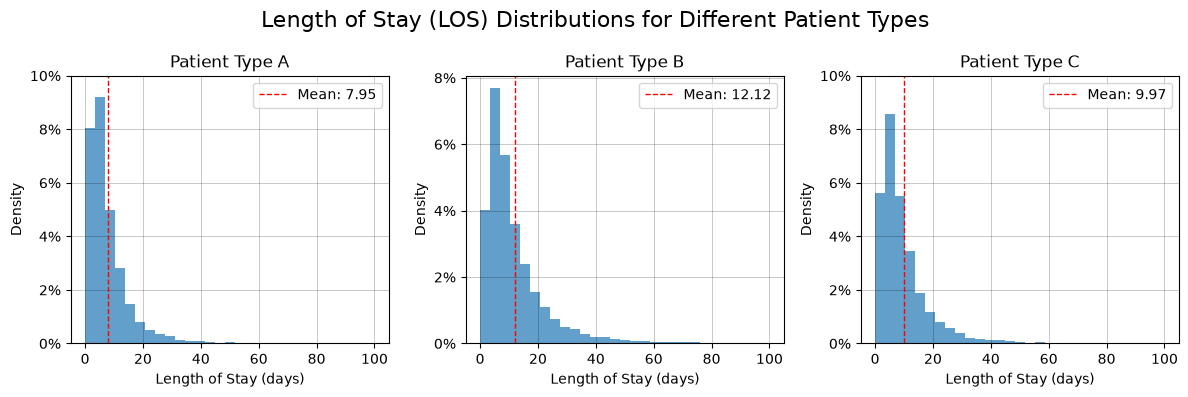

In [5]:
num_samples = 10000
los_A = sample_LOS('A', num_samples)
los_B = sample_LOS('B', num_samples)
los_C = sample_LOS('C', num_samples)

bin_count = 30
is_log = False # if true you can see what log normal distribution means
if is_log:
    bins_A = np.logspace(np.log10(min(los_A)), np.log10(max(los_A)), bin_count)
    bins_B = np.logspace(np.log10(min(los_B)), np.log10(max(los_B)), bin_count)
    bins_C = np.logspace(np.log10(min(los_C)), np.log10(max(los_C)), bin_count)
else:
    bins_A = np.linspace(0, 100, bin_count)
    bins_B = np.linspace(0, 100, bin_count)
    bins_C = np.linspace(0, 100, bin_count)
""" 
bins_A = [0,1,2,3,4,5,6,7,8,9,10,20,30,40,50,60,70,80,90,100,200]
bins_B = [0,1,2,3,4,5,6,7,8,9,10,20,30,40,50,60,70,80,90,100,200]
bins_C = [0,1,2,3,4,5,6,7,8,9,10,20,30,40,50,60,70,80,90,100,200]
"""

hist_A, bins_A = np.histogram(los_A, bins=bins_A, density=True)
hist_B, bins_B = np.histogram(los_B, bins=bins_B, density=True)
hist_C, bins_C = np.histogram(los_C, bins=bins_C, density=True)

fig, axs = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle('Length of Stay (LOS) Distributions for Different Patient Types', fontsize=16)

axs[0].bar(bins_A[:-1]+np.diff(bins_A)/2, hist_A, width=np.diff(bins_A), alpha=0.7)
axs[0].axvline(np.mean(los_A), color='red', linestyle='dashed', linewidth=1, label=f'Mean: {np.mean(los_A):.2f}')
axs[0].set_title('Patient Type A')
axs[0].set_xlabel('Length of Stay (days)')
axs[0].set_ylabel('Density')
if is_log:
    axs[0].set_xscale('log')
    axs[0].set_xticks([1, 2, 5, 10, 20, 50, 100], labels=[1, 2, 5, 10, 20, 50, 100])
axs[0].set_yticks(np.arange(0, max(hist_A)+ 0.02, 0.02), labels=[f'{y*100:.0f}%' for y in np.arange(0, max(hist_A) + 0.02, 0.02)])
axs[0].legend()
axs[0].grid(True, which='both', linewidth=0.5, color='black', alpha=0.3)

axs[1].bar(bins_B[:-1]+np.diff(bins_B)/2, hist_B, width=np.diff(bins_B), alpha=0.7)
axs[1].axvline(np.mean(los_B), color='red', linestyle='dashed', linewidth=1, label=f'Mean: {np.mean(los_B):.2f}')
axs[1].set_title('Patient Type B')
axs[1].set_xlabel('Length of Stay (days)')
axs[1].set_ylabel('Density')
if is_log:
    axs[1].set_xscale('log')
    axs[1].set_xticks([1, 2, 5, 10, 20, 50, 100], labels=[1, 2, 5, 10, 20, 50, 100])
axs[1].set_yticks(np.arange(0, max(hist_B)+ 0.02, 0.02), labels=[f'{y*100:.0f}%' for y in np.arange(0, max(hist_B) + 0.02, 0.02)])
axs[1].legend()
axs[1].grid(True, which='both', linewidth=0.5, color='black', alpha=0.3)

axs[2].bar(bins_C[:-1]+np.diff(bins_C)/2, hist_C, width=np.diff(bins_C), alpha=0.7)
axs[2].axvline(np.mean(los_C), color='red', linestyle='dashed', linewidth=1, label=f'Mean: {np.mean(los_C):.2f}')
axs[2].set_title('Patient Type C')
axs[2].set_xlabel('Length of Stay (days)')
axs[2].set_ylabel('Density')
if is_log:
    axs[2].set_xscale('log')
    axs[2].set_xticks([1, 2, 5, 10, 20, 50, 100], labels=[1, 2, 5, 10, 20, 50, 100])
axs[2].set_yticks(np.arange(0, max(hist_C)+ 0.02, 0.02), labels=[f'{y*100:.0f}%' for y in np.arange(0, max(hist_C) + 0.02, 0.02)])
axs[2].legend()
axs[2].grid(True, which='both', linewidth=0.5, color='black', alpha=0.3)

plt.tight_layout()
plt.show()

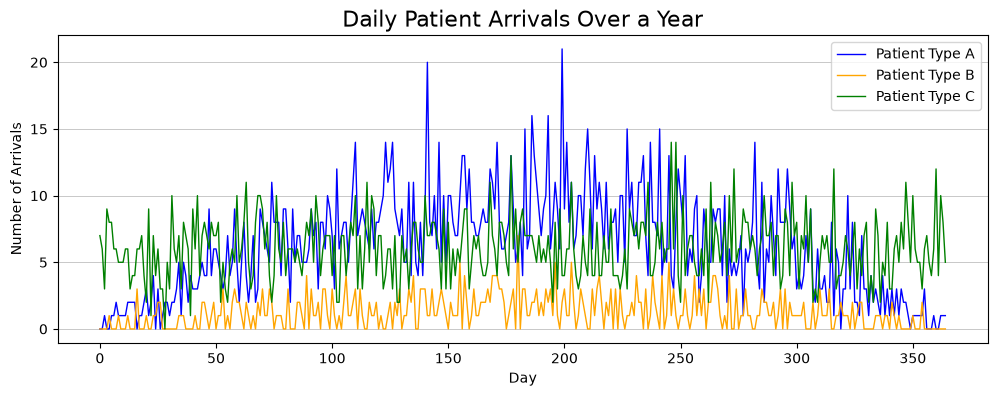

In [6]:
arrivals_A = []
arrivals_B = []
arrivals_C = []

for t in range(0, 365):
    arrivals_A.append(sample_arrivals('A', t))
    arrivals_B.append(sample_arrivals('B', t))
    arrivals_C.append(sample_arrivals('C', t))

plt.figure(figsize=(12, 4))
plt.plot(range(0, 365), arrivals_A, label='Patient Type A', color='blue', linewidth=1)
plt.plot(range(0, 365), arrivals_B, label='Patient Type B', color='orange', linewidth=1)
plt.plot(range(0, 365), arrivals_C, label='Patient Type C', color='green', linewidth=1)
plt.title('Daily Patient Arrivals Over a Year', fontsize=16)
plt.xlabel('Day')
plt.ylabel('Number of Arrivals')
plt.legend()
plt.grid(True, axis='y', linewidth=0.5, color='black', alpha=0.3)
plt.show()

In [7]:
# Uses existing n_runs from the notebook
n_runs = 10000
days = np.arange(365)

# Store every observed arrival count: shape = (run, day)
observed_arrivals_A = np.zeros((n_runs, 365), dtype=int)
observed_arrivals_B = np.zeros((n_runs, 365), dtype=int)
observed_arrivals_C = np.zeros((n_runs, 365), dtype=int)

for run in range(n_runs):
    for t in days:
        observed_arrivals_A[run, t] = sample_arrivals('A', t)
        observed_arrivals_B[run, t] = sample_arrivals('B', t)
        observed_arrivals_C[run, t] = sample_arrivals('C', t)

# Daily stats from all observations
average_arrivals_A = observed_arrivals_A.mean(axis=0)
average_arrivals_B = observed_arrivals_B.mean(axis=0)
average_arrivals_C = observed_arrivals_C.mean(axis=0)

min_arrivals_A = observed_arrivals_A.min(axis=0)
min_arrivals_B = observed_arrivals_B.min(axis=0)
min_arrivals_C = observed_arrivals_C.min(axis=0)

max_arrivals_A = observed_arrivals_A.max(axis=0)
max_arrivals_B = observed_arrivals_B.max(axis=0)
max_arrivals_C = observed_arrivals_C.max(axis=0)

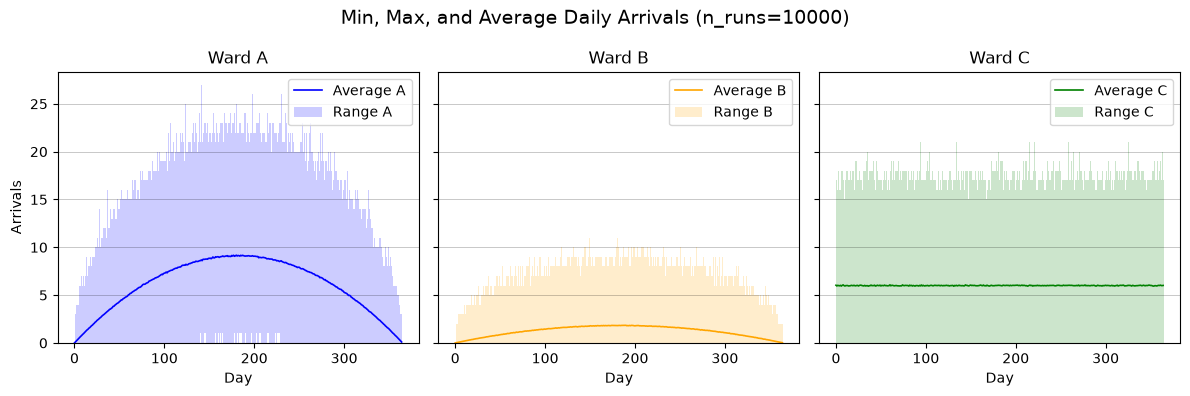

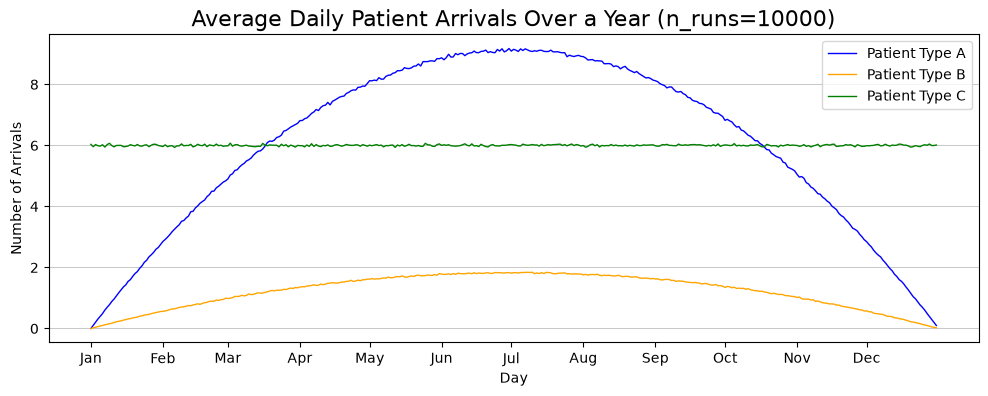

In [8]:
plt.style.use("default")
# (1,3) plot: min-max range + average
fig, axs = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
series = [
    ("A", min_arrivals_A, max_arrivals_A, average_arrivals_A, "blue"),
    ("B", min_arrivals_B, max_arrivals_B, average_arrivals_B, "orange"),
    ("C", min_arrivals_C, max_arrivals_C, average_arrivals_C, "green"),
]

axs[0].set_ylabel("Arrivals")
for ax, (label, mn, mx, avg, color) in zip(axs, series):
    ax.bar(days, mx - mn, bottom=mn, width=1, color=color, alpha=0.2, label=f"Range {label}")
    ax.plot(days, avg, color=color, linewidth=1.2, label=f"Average {label}")
    ax.set_xlabel("Day")
    ax.set_title(f"Ward {label}")
    ax.legend()
    ax.grid(True, axis='y', linewidth=0.5, color='black', alpha=0.3)

fig.suptitle(f"Min, Max, and Average Daily Arrivals (n_runs={n_runs})", fontsize=14)

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(days, average_arrivals_A, label='Patient Type A', color='blue', linewidth=1)
plt.plot(days, average_arrivals_B, label='Patient Type B', color='orange', linewidth=1)
plt.plot(days, average_arrivals_C, label='Patient Type C', color='green', linewidth=1)
plt.title(f'Average Daily Patient Arrivals Over a Year (n_runs={n_runs})', fontsize=16)
plt.xlabel('Day')
plt.xticks([0, 31, 59, 90, 120, 151, 181, 212, 243, 273, 304, 334], labels=["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
plt.ylabel('Number of Arrivals')
plt.legend()
plt.grid(True, axis='y', linewidth=0.5, color='black', alpha=0.3)

In [9]:
# estimate the "demand" for each ward from the average arrivals and the average length of stay
demand_A = np.zeros(365)
demand_B = np.zeros(365)
demand_C = np.zeros(365)

for t in range(365):
    demand_A[t:t+int(np.round(np.mean(los_A)))] += average_arrivals_A[t]
    demand_B[t:t+int(np.round(np.mean(los_B)))] += average_arrivals_B[t]
    demand_C[t:t+int(np.round(np.mean(los_C)))] += average_arrivals_C[t]

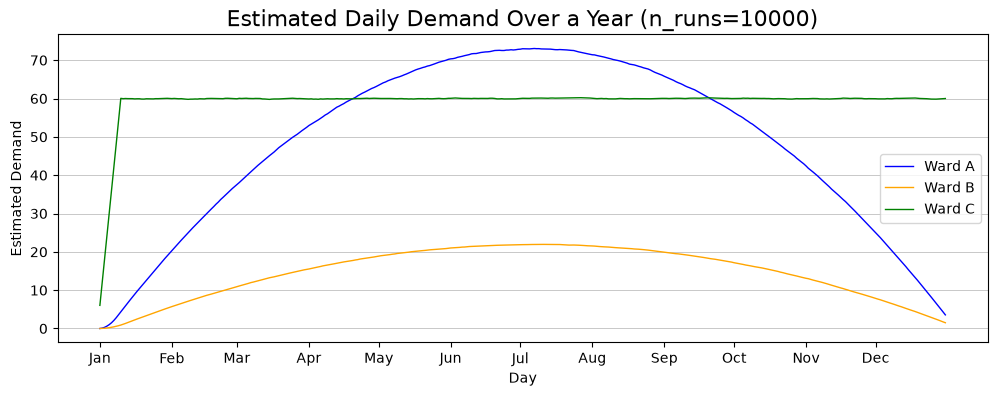

In [10]:
plt.figure(figsize=(12, 4))
# plot the demand for each ward
plt.plot(days, demand_A, label='Ward A', color='blue', linewidth=1)
plt.plot(days, demand_B, label='Ward B', color='orange', linewidth=1)
plt.plot(days, demand_C, label='Ward C', color='green', linewidth=1)
plt.title(f'Estimated Daily Demand Over a Year (n_runs={n_runs})', fontsize=16)
plt.xlabel('Day')
plt.xticks([0, 31, 59, 90, 120, 151, 181, 212, 243, 273, 304, 334], labels=["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
plt.ylabel('Estimated Demand')
plt.legend()
plt.grid(True, axis='y', linewidth=0.5, color='black', alpha=0.3)
plt.show()

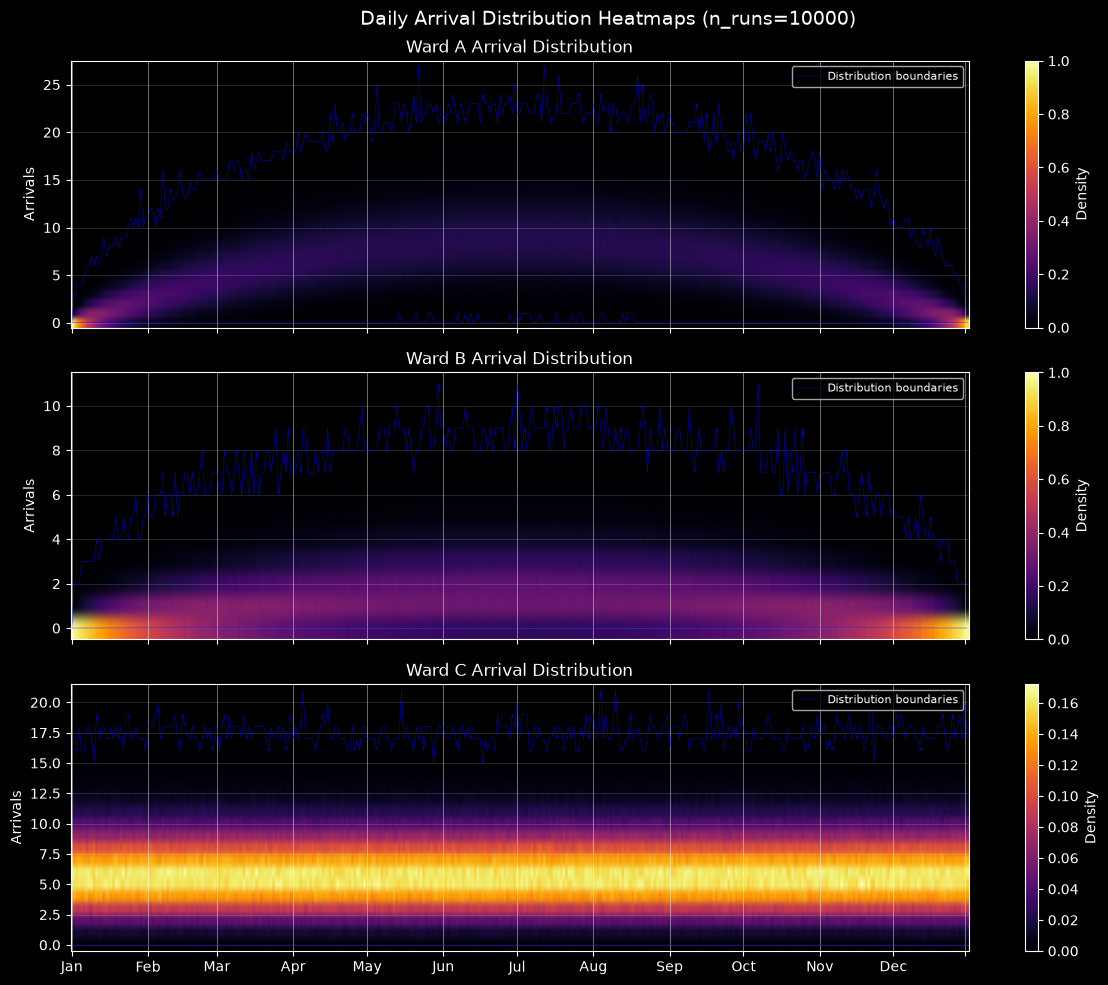

In [11]:
from matplotlib.colors import LogNorm

# Build 2D heatmap data: y=arrival count, x=day, color=frequency across runs
def build_heatmap(obs):
    max_count = obs.max()
    heat = np.zeros((max_count + 1, obs.shape[1]), dtype=int)
    for d in range(obs.shape[1]):
        heat[:, d] = np.bincount(obs[:, d], minlength=max_count + 1)
    return heat

heat_A = (build_heatmap(observed_arrivals_A)/n_runs)
heat_B = (build_heatmap(observed_arrivals_B)/n_runs)
heat_C = (build_heatmap(observed_arrivals_C)/n_runs)

# if 0 leave be if > 0 then add 1 to avoid log(0) issues
#heat_A[heat_A > 0] += 0.05
#heat_B[heat_B > 0] += 0.05
#heat_C[heat_C > 0] += 0.05

# (3,1) plot: 2D distribution heatmaps with log-scaled colors
plt.style.use('dark_background') 
fig, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
heat_series = [("A", heat_A), ("B", heat_B), ("C", heat_C)]

for ax, (label, heat) in zip(axs, heat_series):
    heat_masked = np.ma.masked_equal(heat, 0)  # hide zeros for log scale
    im = ax.imshow(
        heat_masked,
        origin="lower",
        aspect="auto",
        cmap="inferno",
        vmin=0
    )
    ax.set_title(f"Ward {label} Arrival Distribution")
    #ax.set_xlabel("Day")
    ax.set_xticks([0, 31, 59, 90, 120, 151, 181, 212, 243, 273, 304, 334, 363], 
                  labels=["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec", ""])
    ax.set_ylabel("Arrivals")
    ax.grid(True, axis='y', linewidth=0.5, color='white', alpha=0.2)
    ax.grid(True, axis='x', linewidth=0.5, color='white', alpha=0.6)

    # plot at min and max arrival counts for each day
    ax.plot(days, min_arrivals_A if label == "A" else min_arrivals_B if label == "B" else min_arrivals_C, color='blue', linewidth=0.3, label="Distribution boundaries")
    ax.plot(days, max_arrivals_A if label == "A" else max_arrivals_B if label == "B" else max_arrivals_C, color='blue', linewidth=0.3)
    ax.legend(loc='upper right', fontsize=8)
    plt.colorbar(im, ax=ax, label="Density")

fig.suptitle(f"Daily Arrival Distribution Heatmaps (n_runs={n_runs})", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
from math import ceil

def simulate_hospital(capacity_A=0, capacity_B=0, capacity_C=75, exponential=False):
    ward_A = np.zeros((365,), dtype=int)
    ward_B = np.zeros((365,), dtype=int)
    ward_C = np.zeros((365,), dtype=int)

    ward_A_rejects = np.zeros((365,), dtype=int) # on a given day, how many patients of type A were rejected because ward A was full
    ward_B_rejects = np.zeros((365,), dtype=int) # on a given day, how many patients of type B were rejected because both ward B and A were full
    ward_B2A_rejects = np.zeros((365,), dtype=int) # on a given day, how many ward B got relocated to ward A because ward B was full
    ward_C_rejects = np.zeros((365,), dtype=int)

    arrivals_A = np.zeros((365,), dtype=int)
    arrivals_B = np.zeros((365,), dtype=int)
    arrivals_C = np.zeros((365,), dtype=int)

    for t in range(365):

        # allocate ward C first, if capacity is full relocate to different hospital
        arrivals = sample_arrivals('C', t)
        arrivals_C[t] = arrivals
        LOS_C = sample_LOS('C', arrivals)
        while ward_C[t] < capacity_C and arrivals > 0:
            length_of_stay = ceil(LOS_C[arrivals-1])
            ward_C[t:t+length_of_stay] += 1
            arrivals -= 1
        if arrivals > 0:
            ward_C_rejects[t] = arrivals
        
        # allocate ward B next, if capacity is full relocate to ward A, if that is also full relocate to different hospital
        arrivals = sample_arrivals('B', t)
        arrivals_B[t] = arrivals
        LOS_B = sample_LOS('B', arrivals)
        while ward_B[t] < capacity_B and arrivals > 0:
            length_of_stay = ceil(LOS_B[arrivals-1])
            ward_B[t:t+length_of_stay] += 1
            arrivals -= 1
        if arrivals > 0:
            while ward_A[t] < capacity_A and arrivals > 0:
                length_of_stay = ceil(LOS_B[arrivals-1])
                ward_A[t:t+length_of_stay] += 1
                ward_B2A_rejects[t] += 1
                arrivals -= 1
            if arrivals > 0:
                ward_B_rejects[t] = arrivals
        
        # allocate ward A last, if capacity is full relocate to different hospital
        arrivals = sample_arrivals('A', t)
        arrivals_A[t] = arrivals
        LOS_A = sample_LOS('A', arrivals)
        while ward_A[t] < capacity_A and arrivals > 0:
            length_of_stay = ceil(LOS_A[arrivals-1])
            ward_A[t:t+length_of_stay] += 1
            arrivals -= 1
        if arrivals > 0:
            ward_A_rejects[t] = arrivals

    return (ward_A, ward_B, ward_C, 
            ward_A_rejects, ward_B_rejects, ward_B2A_rejects, ward_C_rejects, 
            arrivals_A, arrivals_B, arrivals_C,
            capacity_A, capacity_B, capacity_C)


In [2]:

def simulate_hospital_optimized(capacity_A=0, capacity_B=0, capacity_C=75, n_runs=1, average=False):
    """
    Optimized hospital simulation supporting multiple runs.

    Key improvements over simulate_hospital():
    - Pre-computes arrival rates and LOS params once outside all loops
    - Replaces O(LOS) slice updates  ward[t:t+los] += 1  with O(1) departure-marker
      writes into a diff array; occupancy is tracked with a running integer counter
    - Uses np.add.at for vectorized scatter of all departure days in one call,
      removing the per-patient Python loop
    - Direct admitted count via min/max replaces the while-loop gate check

    Returns:
      n_runs == 1 -> 1D arrays of shape (365,)  — drop-in for simulate_hospital()
      n_runs  > 1 -> 2D arrays of shape (n_runs, 365) for aggregation across runs
    """
    # LOS lognormal parameters (computed once)
    mu_A  = np.log(4 * np.sqrt(2))
    mu_B  = np.log(6 * np.sqrt(2))
    mu_C  = np.log(5 * np.sqrt(2))
    sigma = np.sqrt(np.log(2))

    # Pre-compute daily arrival rates (computed once, not per day per run)
    days   = np.arange(365)
    rate_A = -(1/3650) * days**2 + (1/10) * days   # shape (365,)
    rate_B = rate_A / 5

    # Output arrays — shape (n_runs, 365)
    out_ward_A  = np.zeros((n_runs, 365), dtype=int)
    out_ward_B  = np.zeros((n_runs, 365), dtype=int)
    out_ward_C  = np.zeros((n_runs, 365), dtype=int)
    out_rej_A   = np.zeros((n_runs, 365), dtype=int)
    out_rej_B   = np.zeros((n_runs, 365), dtype=int)
    out_rej_B2A = np.zeros((n_runs, 365), dtype=int)
    out_rej_C   = np.zeros((n_runs, 365), dtype=int)
    out_arr_A   = np.zeros((n_runs, 365), dtype=int)
    out_arr_B   = np.zeros((n_runs, 365), dtype=int)
    out_arr_C   = np.zeros((n_runs, 365), dtype=int)

    for run in range(n_runs):
        # diff[t] accumulates -1 for each patient departing on day t.
        # Size 366: departures beyond day 364 clamp to index 365 and are ignored.
        diff_A = np.zeros(366, dtype=int)
        diff_B = np.zeros(366, dtype=int)
        diff_C = np.zeros(366, dtype=int)

        # Running occupancy counters — avoids array reads inside the hot loop
        occ_A = occ_B = occ_C = 0

        for t in range(365):
            # Apply departures scheduled for today
            occ_A += diff_A[t]
            occ_B += diff_B[t]
            occ_C += diff_C[t]

            # ── Ward C ─────────────────────────────────────────────────────────
            n = np.random.poisson(6)
            out_arr_C[run, t] = n
            admitted = min(n, max(0, capacity_C - occ_C))
            if admitted > 0:
                los = np.ceil(np.random.lognormal(mu_C, sigma, admitted)).astype(int)
                np.add.at(diff_C, np.minimum(t + los, 365), -1)
                occ_C += admitted
            out_rej_C[run, t] = n - admitted

            # ── Ward B (overflow → Ward A) ──────────────────────────────────────
            n = np.random.poisson(rate_B[t])
            out_arr_B[run, t] = n
            admitted_B = min(n, max(0, capacity_B - occ_B))
            if admitted_B > 0:
                los = np.ceil(np.random.lognormal(mu_B, sigma, admitted_B)).astype(int)
                np.add.at(diff_B, np.minimum(t + los, 365), -1)
                occ_B += admitted_B
            overflow = n - admitted_B
            if overflow > 0:
                los_ovf = np.ceil(np.random.lognormal(mu_B, sigma, overflow)).astype(int)
                b2a = min(overflow, max(0, capacity_A - occ_A))
                if b2a > 0:
                    np.add.at(diff_A, np.minimum(t + los_ovf[:b2a], 365), -1)
                    occ_A += b2a
                out_rej_B2A[run, t] = b2a
                out_rej_B[run, t]   = overflow - b2a

            # ── Ward A ─────────────────────────────────────────────────────────
            n = np.random.poisson(rate_A[t])
            out_arr_A[run, t] = n
            admitted_A = min(n, max(0, capacity_A - occ_A))
            if admitted_A > 0:
                los = np.ceil(np.random.lognormal(mu_A, sigma, admitted_A)).astype(int)
                np.add.at(diff_A, np.minimum(t + los, 365), -1)
                occ_A += admitted_A
            out_rej_A[run, t] = n - admitted_A

            # Record occupancy after today's admissions
            out_ward_A[run, t] = occ_A
            out_ward_B[run, t] = occ_B
            out_ward_C[run, t] = occ_C

    # Squeeze to 1D when n_runs == 1 so it's a drop-in for simulate_hospital()
    if n_runs == 1:
        return (out_ward_A[0], out_ward_B[0], out_ward_C[0],
                out_rej_A[0], out_rej_B[0], out_rej_B2A[0], out_rej_C[0],
                out_arr_A[0], out_arr_B[0], out_arr_C[0],
                capacity_A, capacity_B, capacity_C)

    if average:
        out_ward_A  = out_ward_A.mean(axis=0)
        out_ward_B  = out_ward_B.mean(axis=0)
        out_ward_C  = out_ward_C.mean(axis=0)
        out_rej_A   = out_rej_A.mean(axis=0)
        out_rej_B   = out_rej_B.mean(axis=0)
        out_rej_B2A = out_rej_B2A.mean(axis=0)
        out_rej_C   = out_rej_C.mean(axis=0)
        out_arr_A   = out_arr_A.mean(axis=0)
        out_arr_B   = out_arr_B.mean(axis=0)
        out_arr_C   = out_arr_C.mean(axis=0)

    return (out_ward_A, out_ward_B, out_ward_C,
            out_rej_A, out_rej_B, out_rej_B2A, out_rej_C,
            out_arr_A, out_arr_B, out_arr_C,
            capacity_A, capacity_B, capacity_C)


In [14]:
import time

default_times = {}
optimized_times = {}

for n_runs in [1,2,5,10,100,500,1000]:
    start_time = time.time()
    simulate_hospital_optimized(capacity_A=0, capacity_B=0, capacity_C=75, n_runs=n_runs)
    optimized_times[n_runs] = time.time() - start_time
    print(f"Optimized simulation time for {n_runs} runs: {optimized_times[n_runs]:.4f} seconds")

    start_time = time.time()
    for _ in range(n_runs):
        simulate_hospital(capacity_A=0, capacity_B=0, capacity_C=75)
    default_times[n_runs] = time.time() - start_time
    print(f"Original simulation time for {n_runs} runs: {default_times[n_runs]:.4f} seconds")

Optimized simulation time for 1 runs: 0.0090 seconds
Original simulation time for 1 runs: 0.0150 seconds
Optimized simulation time for 2 runs: 0.0150 seconds
Original simulation time for 2 runs: 0.0212 seconds
Optimized simulation time for 5 runs: 0.0262 seconds
Original simulation time for 5 runs: 0.0493 seconds
Optimized simulation time for 10 runs: 0.0511 seconds
Original simulation time for 10 runs: 0.0963 seconds
Optimized simulation time for 100 runs: 0.5048 seconds
Original simulation time for 100 runs: 0.9788 seconds
Optimized simulation time for 500 runs: 2.5135 seconds
Original simulation time for 500 runs: 4.7787 seconds
Optimized simulation time for 1000 runs: 5.0047 seconds
Original simulation time for 1000 runs: 9.5428 seconds


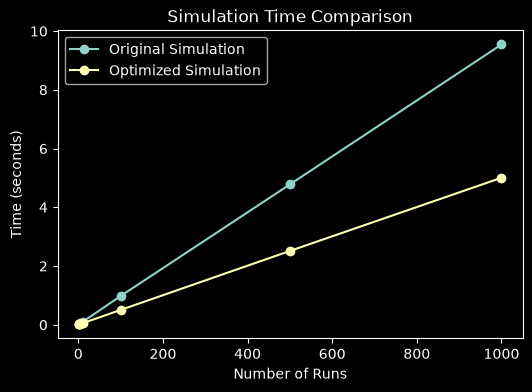

In [15]:
plt.figure(figsize=(6, 4))
plt.plot(list(default_times.keys()), list(default_times.values()), label='Original Simulation', marker='o')
plt.plot(list(optimized_times.keys()), list(optimized_times.values()), label='Optimized Simulation', marker='o')
plt.title('Simulation Time Comparison')
plt.xlabel('Number of Runs')
plt.ylabel('Time (seconds)')
plt.grid(True, axis='y', linewidth=0.5, color='black', alpha=0.3)
plt.legend()
plt.show()


In [7]:
def plot_hospital_simulation_results(ward_A, ward_B, ward_C, ward_A_rejects, ward_B_rejects, ward_B2A_rejects, ward_C_rejects, arrivals_A, arrivals_B, arrivals_C, capacity_A, capacity_B, capacity_C):
    fig, axs = plt.subplots(3, 1, figsize=(8, 8), sharex=True)
    days = np.arange(365)

    axs[0].plot(days, ward_A, label='Ward A Occupancy', color='blue', linewidth=1)
    axs[0].plot(days, ward_B, label='Ward B Occupancy', color='orange', linewidth=1)
    axs[0].plot(days, ward_C, label='Ward C Occupancy', color='green', linewidth=1)
    axs[0].set_title('Ward Occupancy Over a Year')

    axs[1].plot(days, ward_A_rejects, label='Ward A Rejects', color='blue', linewidth=1)
    axs[1].plot(days, ward_B_rejects, label='Ward B Rejects', color='orange', linewidth=1)
    axs[1].plot(days, ward_B2A_rejects, label='Ward B to A Relocations', color='purple', linewidth=1)
    axs[1].plot(days, ward_C_rejects, label='Ward C Rejects', color='green', linewidth=1)
    axs[1].set_title('Ward Rejects Over a Year')

    axs[2].plot(days, arrivals_A, label='Patient Type A Arrivals', color='blue', linewidth=1)
    axs[2].plot(days, arrivals_B, label='Patient Type B Arrivals', color='orange', linewidth=1)
    axs[2].plot(days, arrivals_C, label='Patient Type C Arrivals', color='green', linewidth=1)
    axs[2].set_title('Patient Arrivals Over a Year')

    for ax in axs:
        ax.set_xlabel('Day')
        ax.set_ylabel('Count')
        ax.legend(fontsize=8)
        ax.grid(True, axis='y', linewidth=0.5, color='black', alpha=0.3)
        ax.set_xticks([0, 31, 59, 90, 120, 151, 181, 212, 243, 273, 304, 334], labels=["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])

    fig.suptitle(f'Hospital Simulation Results (Ward A: {capacity_A}, Ward B: {capacity_B}, Ward C: {capacity_C})', fontsize=16)
    plt.tight_layout()

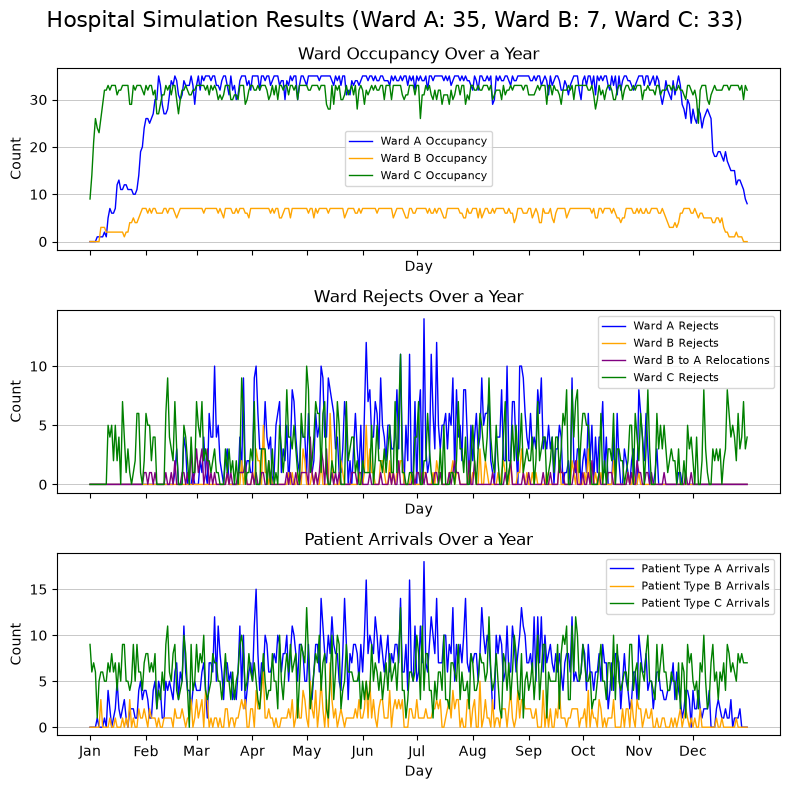

In [ ]:
plt.style.use("default")
plot_hospital_simulation_results(*simulate_hospital_continuous(capacity_A=35, capacity_B=7, capacity_C=33))

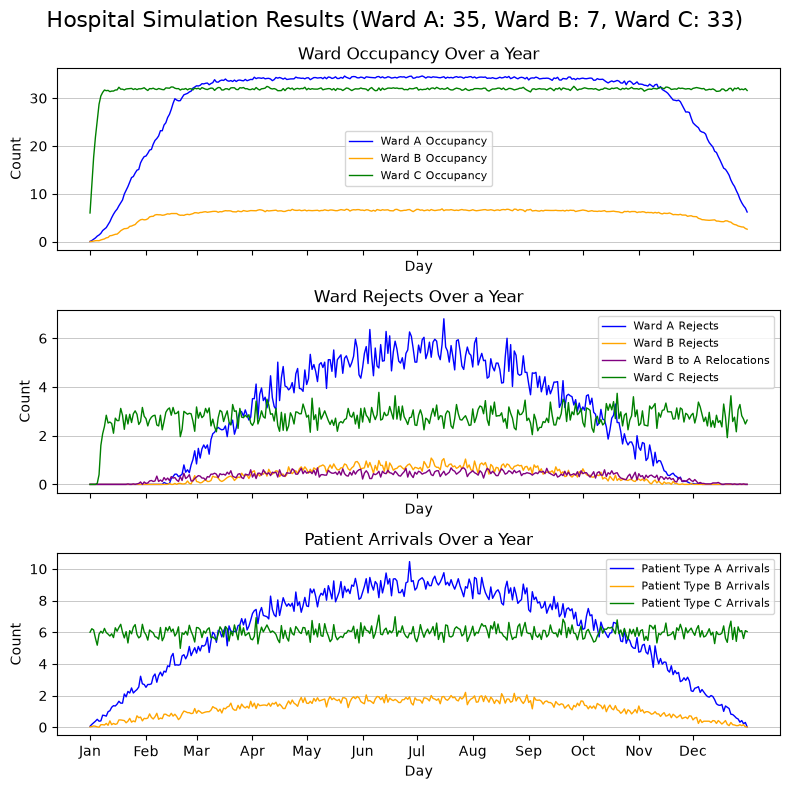

In [14]:
plot_hospital_simulation_results(*simulate_hospital_continuous(capacity_A=35, capacity_B=7, capacity_C=33, n_runs=50))

In [3]:
def sample_configurations(num_samples, num_beds):
    # Number of beds for each ward satisfies
    # Ward_A + Ward_B + Ward_C = num_beds
    # Which lies on a 2D plane in 3D space. We can sample uniformly from this plane.
    configurations = {} # generate all possible configurations
    for ward_C in range(num_beds + 1):
        for ward_B in range(num_beds - ward_C + 1):
            ward_A = num_beds - ward_B - ward_C
            configurations[(ward_A, ward_B, ward_C)] = None
    
    for ward_A, ward_B, ward_C in configurations:
        if ward_A < 0 or ward_B < 0 or ward_C < 0 or (ward_A + ward_B + ward_C) != num_beds:
            raise ValueError(f"Invalid configuration: Ward A: {ward_A}, Ward B: {ward_B}, Ward C: {ward_C}")
        #else:
            #print(f"Valid configuration: Ward A: {ward_A}, Ward B: {ward_B}, Ward C: {ward_C}")

    for ward_A, ward_B, ward_C in configurations:
        ward_A_occupancy, ward_B_occupancy, ward_C_occupancy, ward_A_rejects, ward_B_rejects, ward_B2A_rejects, ward_C_rejects, arrivals_A, arrivals_B, arrivals_C, capacity_A, capacity_B, capacity_C = simulate_hospital_optimized(capacity_A=ward_A, capacity_B=ward_B, capacity_C=ward_C, n_runs=num_samples, average=True)
        configurations[(ward_A, ward_B, ward_C)] = {
            "ward_A_occupancy": ward_A_occupancy,
            "ward_B_occupancy": ward_B_occupancy,
            "ward_C_occupancy": ward_C_occupancy,
            "ward_A_rejects": ward_A_rejects,
            "ward_B_rejects": ward_B_rejects,
            "ward_B2A_rejects": ward_B2A_rejects,
            "ward_C_rejects": ward_C_rejects,
            "arrivals_A": arrivals_A,
            "arrivals_B": arrivals_B,
            "arrivals_C": arrivals_C
        }

    return configurations
            

In [2]:

from joblib import Parallel, delayed

# ── CPU parallel worker (one config per job) ───────────────────────────────────

def _simulate_config(ward_A, ward_B, ward_C, num_samples):
    """Run simulate_hospital_continuous for a single configuration."""
    wA_occ, wB_occ, wC_occ, rA, rB, rB2A, rC, aA, aB, aC, *_ = simulate_hospital_continuous(
        capacity_A=ward_A, capacity_B=ward_B, capacity_C=ward_C,
        n_runs=num_samples, average=True,
    )
    return (ward_A, ward_B, ward_C), {
        "ward_A_occupancy": wA_occ, "ward_B_occupancy": wB_occ, "ward_C_occupancy": wC_occ,
        "ward_A_rejects": rA, "ward_B_rejects": rB, "ward_B2A_rejects": rB2A,
        "ward_C_rejects": rC, "arrivals_A": aA, "arrivals_B": aB, "arrivals_C": aC,
    }


# ── GPU batched worker (all configs × all runs in one vectorised sweep) ────────

def _gpu_batch_simulate(configs_batch, num_samples):
    """
    Simulate a batch of configurations simultaneously on the GPU,
    faithfully replicating the continuous-time logic of simulate_hospital_continuous.

    Within each day, arrivals from all three patient types are combined and
    processed in strict chronological order (sorted by continuous arrival time),
    exactly as the heap-based CPU simulation does. This ensures ward-B overflow
    patients compete with ward-A patients at their actual arrival times rather
    than as a whole batch processed after all A arrivals.

    Departure time per patient = t_arr + LOS (continuous, no ceiling).
    The diff array uses floor(t_arr + LOS) as the first day index at which
    the bed is free, matching the heap flush condition:
        flush(heap, day+1)  removes patients with departure <= day+1
    i.e. a patient is absent from occ[d] when departure <= d+1,
    so dep_day = floor(departure) (equal to ceil(departure-1) for non-integer
    departure, which is the case with probability 1 for continuous LOS).
    """
    import cupy as cp
    import cupyx

    n_configs = len(configs_batch)
    B = n_configs * num_samples

    configs_np = np.array(configs_batch, dtype=np.int32)
    cap_A = cp.asarray(np.repeat(configs_np[:, 0], num_samples))
    cap_B = cp.asarray(np.repeat(configs_np[:, 1], num_samples))
    cap_C = cp.asarray(np.repeat(configs_np[:, 2], num_samples))

    mu_A  = float(np.log(4 * np.sqrt(2)))
    mu_B  = float(np.log(6 * np.sqrt(2)))
    mu_C  = float(np.log(5 * np.sqrt(2)))
    sigma = float(np.sqrt(np.log(2)))

    t_idx  = np.arange(365)
    rate_A = -(1 / 3650) * t_idx**2 + (1 / 10) * t_idx
    rate_B = rate_A / 5

    diff_A = cp.zeros(B * 366, dtype=cp.int32)
    diff_B = cp.zeros(B * 366, dtype=cp.int32)
    diff_C = cp.zeros(B * 366, dtype=cp.int32)

    occ_A = cp.zeros(B, dtype=cp.int32)
    occ_B = cp.zeros(B, dtype=cp.int32)
    occ_C = cp.zeros(B, dtype=cp.int32)

    keys = ["ward_A_occupancy", "ward_B_occupancy", "ward_C_occupancy",
            "ward_A_rejects",   "ward_B_rejects",   "ward_B2A_rejects",
            "ward_C_rejects",   "arrivals_A",        "arrivals_B",   "arrivals_C"]
    out = {k: cp.zeros((B, 365), dtype=cp.float32) for k in keys}

    b_off = cp.arange(B, dtype=cp.int64) * 366

    # Safe per-type upper bounds on daily Poisson arrivals:
    #   rate_A peaks at ~9.1  → MAX_A=30 covers >6σ
    #   rate_B peaks at ~1.8  → MAX_B=15 is very safe
    #   rate_C = 6 constant   → MAX_C=22 covers >6σ
    MAX_A, MAX_B, MAX_C = 30, 15, 22
    MAX_TOTAL = MAX_A + MAX_B + MAX_C   # 67

    k_A = cp.arange(MAX_A, dtype=cp.int32)
    k_B = cp.arange(MAX_B, dtype=cp.int32)
    k_C = cp.arange(MAX_C, dtype=cp.int32)

    # Patient-type label per slot (0=A, 1=B, 2=C); tiled once, reused every day
    ptype_row = cp.concatenate([
        cp.zeros(MAX_A, dtype=cp.int32),
        cp.ones(MAX_B,  dtype=cp.int32),
        cp.full(MAX_C, 2, dtype=cp.int32),
    ])  # (MAX_TOTAL,)
    all_ptype = cp.tile(ptype_row, (B, 1))  # (B, MAX_TOTAL), same every day

    for t in range(365):
        # Apply integer-day departures that become effective today
        occ_A += diff_A[b_off + t]
        occ_B += diff_B[b_off + t]
        occ_C += diff_C[b_off + t]

        # ── Sample arrival counts and clip to slot budget ──────────────────────
        n_A = cp.minimum(cp.random.poisson(float(rate_A[t]), B), MAX_A).astype(cp.int32)
        n_B = cp.minimum(cp.random.poisson(float(rate_B[t]), B), MAX_B).astype(cp.int32)
        n_C = cp.minimum(cp.random.poisson(6.0, B),            MAX_C).astype(cp.int32)
        out["arrivals_A"][:, t] = n_A
        out["arrivals_B"][:, t] = n_B
        out["arrivals_C"][:, t] = n_C

        # ── Sample LOS and continuous arrival times within [t, t+1) ───────────
        los_A_s = cp.random.lognormal(mu_A, sigma, (B, MAX_A))
        los_B_s = cp.random.lognormal(mu_B, sigma, (B, MAX_B))
        los_C_s = cp.random.lognormal(mu_C, sigma, (B, MAX_C))
        u_A = t + cp.random.uniform(0.0, 1.0, (B, MAX_A))
        u_B = t + cp.random.uniform(0.0, 1.0, (B, MAX_B))
        u_C = t + cp.random.uniform(0.0, 1.0, (B, MAX_C))

        # ── Validity masks; push unused slots past day boundary so they sort last
        valid_A = k_A[None, :] < n_A[:, None]   # (B, MAX_A)
        valid_B = k_B[None, :] < n_B[:, None]
        valid_C = k_C[None, :] < n_C[:, None]
        u_A = cp.where(valid_A, u_A, float(t + 1))
        u_B = cp.where(valid_B, u_B, float(t + 1))
        u_C = cp.where(valid_C, u_C, float(t + 1))

        # ── Merge all arrivals into (B, MAX_TOTAL) tensors ─────────────────────
        all_u     = cp.concatenate([u_A,     u_B,     u_C    ], axis=1)
        all_los   = cp.concatenate([los_A_s, los_B_s, los_C_s], axis=1)
        all_valid = cp.concatenate([valid_A, valid_B, valid_C], axis=1)

        # ── Sort each trajectory's arrivals by continuous arrival time ──────────
        sort_idx    = cp.argsort(all_u, axis=1)                          # (B, MAX_TOTAL)
        all_u_s     = cp.take_along_axis(all_u,     sort_idx, axis=1)
        all_los_s   = cp.take_along_axis(all_los,   sort_idx, axis=1)
        all_valid_s = cp.take_along_axis(all_valid, sort_idx, axis=1)
        all_ptype_s = cp.take_along_axis(all_ptype, sort_idx, axis=1)

        # ── Process arrivals one slot at a time in chronological order ──────────
        for i in range(MAX_TOTAL):
            t_arr_i = all_u_s[:, i]         # (B,) continuous arrival time
            los_i   = all_los_s[:, i]       # (B,) length of stay
            valid_i = all_valid_s[:, i]     # (B,) bool: real patient?
            ptype_i = all_ptype_s[:, i]     # (B,) int:  0=A, 1=B, 2=C

            # First day the bed is free = floor(departure time), clamped to 365
            dep_day = cp.minimum(cp.floor(t_arr_i + los_i).astype(cp.int64), 365)
            dep_idx = b_off + dep_day       # index into flat diff arrays

            # ── Ward C ──────────────────────────────────────────────────────────
            is_C    = valid_i & (ptype_i == 2)
            adm_C   = is_C & (occ_C < cap_C)
            adm_C_i = adm_C.astype(cp.int32)
            cupyx.scatter_add(diff_C, dep_idx, -adm_C_i)
            occ_C   = occ_C + adm_C_i
            out["ward_C_rejects"][:, t] += (is_C & ~adm_C).astype(cp.float32)

            # ── Ward B (overflow → Ward A) ───────────────────────────────────────
            is_B    = valid_i & (ptype_i == 1)
            adm_B   = is_B & (occ_B < cap_B)
            adm_B_i = adm_B.astype(cp.int32)
            cupyx.scatter_add(diff_B, dep_idx, -adm_B_i)
            occ_B   = occ_B + adm_B_i
            ovfl    = is_B & ~adm_B
            b2a     = ovfl & (occ_A < cap_A)
            b2a_i   = b2a.astype(cp.int32)
            cupyx.scatter_add(diff_A, dep_idx, -b2a_i)
            occ_A   = occ_A + b2a_i
            out["ward_B2A_rejects"][:, t] += b2a.astype(cp.float32)
            out["ward_B_rejects"][:, t]   += (ovfl & ~b2a).astype(cp.float32)

            # ── Ward A ───────────────────────────────────────────────────────────
            is_A    = valid_i & (ptype_i == 0)
            adm_A   = is_A & (occ_A < cap_A)
            adm_A_i = adm_A.astype(cp.int32)
            cupyx.scatter_add(diff_A, dep_idx, -adm_A_i)
            occ_A   = occ_A + adm_A_i
            out["ward_A_rejects"][:, t] += (is_A & ~adm_A).astype(cp.float32)

        out["ward_A_occupancy"][:, t] = occ_A
        out["ward_B_occupancy"][:, t] = occ_B
        out["ward_C_occupancy"][:, t] = occ_C

    # Average over runs → (n_configs, 365), transfer back to numpy
    averaged = {
        k: v.reshape(n_configs, num_samples, 365).mean(axis=1).get()
        for k, v in out.items()
    }
    return averaged

# ── Public API ─────────────────────────────────────────────────────────────────

def sample_configurations_optimized(num_samples, num_beds, backend='cpu', n_jobs=-1, gpu_chunk=None):
    """
    Sample all valid bed configurations (ward_A + ward_B + ward_C == num_beds).

    Parameters
    ----------
    num_samples : int   – simulation runs per configuration
    num_beds    : int   – total bed count
    backend     : str   – 'cpu'  → joblib Parallel across all cores
                          'gpu'  → CuPy batched GPU (requires cupy-cudaXX)
    n_jobs      : int   – CPU cores for backend='cpu'  (-1 = all)
    gpu_chunk   : int   – configs per GPU batch; tune down if you hit OOM
                          (None = all configs in one batch)

    Returns the same dict format as sample_configurations().
    """
    configs = [
        (num_beds - ward_B - ward_C, ward_B, ward_C)
        for ward_C in range(num_beds + 1)
        for ward_B in range(num_beds - ward_C + 1)
    ]

    if backend == 'gpu':
        try:
            import cupy as cp                               # validate early
            chunk = gpu_chunk or len(configs)
            result = {}
            for i in range(0, len(configs), chunk):
                batch    = configs[i:i + chunk]
                averaged = _gpu_batch_simulate(batch, num_samples)
                for j, key in enumerate(batch):
                    result[key] = {k: averaged[k][j] for k in averaged}
            return result
        except ImportError:
            print("CuPy not found — falling back to CPU parallel.")

    # CPU parallel via joblib / loky (cloudpickle handles notebook-defined fns)
    pairs = Parallel(n_jobs=n_jobs, backend='loky')(
        delayed(_simulate_config)(wA, wB, wC, num_samples)
        for wA, wB, wC in configs
    )
    return dict(pairs)


In [4]:

import time

# ── CPU parallel smoke-test ────────────────────────────────────────────────────
t0 = time.time()
cfg_cpu = sample_configurations_optimized(num_samples=5, num_beds=10, backend='cpu')
print(f"CPU parallel: {len(cfg_cpu)} configs in {time.time()-t0:.2f}s")

# ── GPU smoke-test (skipped gracefully if no CUDA) ────────────────────────────
t0 = time.time()
cfg_gpu = sample_configurations_optimized(num_samples=5, num_beds=10, backend='gpu')
print(f"GPU batched:  {len(cfg_gpu)} configs in {time.time()-t0:.2f}s")

# ── sanity: results should be close ───────────────────────────────────────────
key = (5, 3, 2)
print(f"\nWard A occupancy mean (CPU): {cfg_cpu[key]['ward_A_occupancy'].mean():.2f}")
print(f"Ward A occupancy mean (GPU): {cfg_gpu[key]['ward_A_occupancy'].mean():.2f}")


CPU parallel: 66 configs in 1.94s
GPU batched:  66 configs in 3.87s

Ward A occupancy mean (CPU): 4.82
Ward A occupancy mean (GPU): 4.87


In [ ]:

def plot_configuration_results(configurations, num_beds, statistic="mean"):
    """
    Plot 2D heatmaps (Ward A beds × Ward B beds) for each metric, aggregated
    over the full simulation year using the chosen statistic.

    Parameters
    ----------
    configurations : dict   – output of sample_configurations_optimized()
    num_beds       : int    – total bed count
    statistic      : str    – 'mean' | 'median' | 'max' | 'min' | 'sum'
    """

    def _agg(data):
        if statistic == "mean":   return data.mean()
        if statistic == "median": return np.median(data)
        if statistic == "max":    return data.max()
        if statistic == "min":    return data.min()
        if statistic == "sum":    return data.sum()
        raise ValueError(f"Unknown statistic '{statistic}'. Use mean/median/max/min/sum.")


    display_categories = [
        "ward_A_occupancy", "ward_B_occupancy", "ward_C_occupancy",
        "ward_A_rejects",   "ward_B2A_rejects",   "ward_C_rejects",
        "ward_B_rejects", "relocated_to_other_hospital", "overall_utilization"
    ]
    labels = {
        "ward_A_occupancy": "Ward A Occupancy",
        "ward_B_occupancy": "Ward B Occupancy",
        "ward_C_occupancy": "Ward C Occupancy",
        "ward_A_rejects": "Ward A relocated to Other Hospital",
        "ward_B_rejects": "Ward B relocated to Other Hospital",
        "ward_C_rejects": "Ward C relocated to Other Hospital",
        "ward_B2A_rejects": "Ward B to A Relocations",
        "relocated_to_other_hospital": "Total relocated to Other Hospital",
        "overall_utilization": "Overall Utilization"
    }


    heatmaps = {cat: np.zeros((num_beds + 1, num_beds + 1)) for cat in display_categories}
    valid_mask = np.zeros((num_beds + 1, num_beds + 1), dtype=bool)
    # create a mask for b2a relocations where ward_B_to_A_rejects/ward_B_arrivals is under
    # a certain threshold (e.g., 0.1) to limit how many people are relocated to ward A from ward B.
    # mask later used to limit the search for min and max in utilization and other hospital relocation heatmaps
    b2a_mask = np.zeros((num_beds + 1, num_beds + 1), dtype=bool)
    b2a_threshold = 0.2

    for (ward_A, ward_B, ward_C), results in configurations.items():
        valid_mask[ward_A, ward_B] = True
        b_arrivals_total = np.asarray(results["arrivals_B"]).sum()
        b2a_total = np.asarray(results["ward_B_rejects"]).sum()
        ratio = (b2a_total / b_arrivals_total) if b_arrivals_total > 0 else 0.0
        b2a_mask[ward_A, ward_B] = ratio < b2a_threshold

        for cat in display_categories:
            if cat == "relocated_to_other_hospital":
                data = results["ward_A_rejects"] + results["ward_B_rejects"] + results["ward_C_rejects"]
            elif cat == "overall_utilization":
                total_occ = results["ward_A_occupancy"] + results["ward_B_occupancy"] + results["ward_C_occupancy"]
                data = total_occ / num_beds
            else:
                data = results[cat]
            heatmaps[cat][ward_A, ward_B] = _agg(data)

    fig, axs = plt.subplots(3, 3, figsize=(15, 12))
    for cat, ax in zip(display_categories, axs.flatten()):
        if cat == "overall_utilization":
            if statistic == "sum":
                vmin, vmax = 0, 365
            else:
                vmin, vmax = 0, 1
        else:
            vmin, vmax = None, None
        im = ax.imshow(
            heatmaps[cat],
            origin='lower',
            cmap='viridis',
            extent=[0, num_beds, 0, num_beds],
            vmin=vmin, vmax=vmax
        )
        ax.set_title(labels[cat])
        #ax.set_title(cat.replace("_", " ").title())
        ax.set_xlabel('Ward B Beds')
        ax.set_ylabel('Ward A Beds')
        # Source - https://stackoverflow.com/a/26720422
        # Posted by skytaker
        # Retrieved 2026-06-26, License - CC BY-SA 3.0
        # plt.colorbar(im,fraction=0.046, pad=0.04) <- fix the damn colorbar size

        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        def mask_edges(mask, ax):
            x_min, x_max, y_min, y_max = im.get_extent()
            rows, cols = mask.shape
            dx = (x_max - x_min) / cols
            dy = (y_max - y_min) / rows

            for ward_A, ward_B in np.argwhere(mask):
                x0 = x_min + ward_B * dx
                x1 = x_min + (ward_B + 1) * dx
                y0 = y_min + ward_A * dy
                y1 = y_min + (ward_A + 1) * dy

                # top edge
                if ward_A + 1 >= rows or not mask[ward_A + 1, ward_B]:
                    ax.plot([x0, x1], [y1, y1], color='white', lw=1, zorder=6, clip_on=True)
                # bottom edge
                if ward_A - 1 < 0 or not mask[ward_A - 1, ward_B]:
                    ax.plot([x0, x1], [y0, y0], color='white', lw=1, zorder=6, clip_on=True)
                # right edge
                if ward_B + 1 >= cols or not mask[ward_A, ward_B + 1]:
                    ax.plot([x1, x1], [y0, y1], color='white', lw=1, zorder=6, clip_on=True)
                # left edge
                if ward_B - 1 < 0 or not mask[ward_A, ward_B - 1]:
                    ax.plot([x0, x0], [y0, y1], color='white', lw=1, zorder=6, clip_on=True)

        masked = np.where(b2a_mask, heatmaps[cat], np.nan)
        non_masked = np.where(valid_mask, heatmaps[cat], np.nan)
        if cat == "relocated_to_other_hospital":
            idx = np.unravel_index(np.nanargmin(masked), masked.shape)
            val = heatmaps[cat][idx]
            label = f'Min: {val:.1f}\nA={idx[0]} B={idx[1]} C={num_beds-idx[0]-idx[1]}'
            ax.plot(idx[1], idx[0], 'r.', markersize=10, zorder=7)

            idx2 = np.unravel_index(np.nanargmin(non_masked), non_masked.shape)
            val2 = heatmaps[cat][idx2]
            label2 = f'Min: {val2:.1f}\nA={idx2[0]} B={idx2[1]} C={num_beds-idx2[0]-idx2[1]}'
            ax.plot(idx2[1], idx2[0], 'r.', markersize=10, zorder=7)
            print(idx, idx2)
            
            max_reloc = np.nanmax(masked)
            min_reloc = np.nanmin(masked)
            range_reloc = max_reloc - min_reloc
            for percentile in np.linspace(0.0,1.0,11):
                threshold = min_reloc + percentile * range_reloc
                mask = (masked >= threshold)
                mask_edges(mask, ax)

            ax.annotate(label, xy=(idx[1], idx[0]), xytext=(10, -10),
                        textcoords='offset points', color='black', fontsize=10, fontweight='bold',
                        arrowprops=dict(arrowstyle='->', color='black', lw=1.2), zorder=7)
            ax.annotate(label2, xy=(idx2[1], idx2[0]), xytext=(0, 10),
                        textcoords='offset points', color='black', fontsize=10, fontweight='bold',
                        arrowprops=dict(arrowstyle='->', color='black', lw=1.2), zorder=7)
            
            ax.plot([], [], color='white', lw=2, label=f'gradient')
            ax.legend(loc='upper right', fontsize=10)

        elif cat == "overall_utilization": # utilization measure at min relocation point
            # idx = np.unravel_index(np.nanargmax(masked), masked.shape) uncomment to find the max utilization point
            val = heatmaps[cat][idx]
            label = f'{val:.3f}'
            ax.plot(idx[1], idx[0], 'r.', markersize=10, zorder=7)

            val2 = heatmaps[cat][idx2]
            label2 = f'{val2:.3f}'
            ax.plot(idx2[1], idx2[0], 'r.', markersize=10, zorder=7)
            
            max_util = np.nanmax(masked)
            min_util = np.nanmin(masked)
            range_util = max_util - min_util
            for percentile in np.linspace(0.0,1.0,11):
                threshold = min_util + percentile * range_util
                mask = (masked >= threshold)
                mask_edges(mask, ax)

            ax.annotate(label, xy=(idx[1], idx[0]), xytext=(10, -10),
                        textcoords='offset points', color='black', fontsize=10, fontweight='bold',
                        arrowprops=dict(arrowstyle='->', color='black', lw=1.2), zorder=7)
            ax.annotate(label2, xy=(idx2[1], idx2[0]), xytext=(10, 20),
                        textcoords='offset points', color='black', fontsize=10, fontweight='bold',
                        arrowprops=dict(arrowstyle='->', color='black', lw=1.2), zorder=7)
            
            ax.plot([], [], color='white', lw=2, label=f'gradient')
            ax.legend(loc='upper right', fontsize=10)
        

        elif cat == "ward_B_rejects":
            mask_edges(b2a_mask, ax)

            idx = (38,13)
            val = heatmaps[cat][idx]
            label = f'{val:.1f}'
            ax.plot(idx[1], idx[0], 'r.', markersize=10, zorder=7)

            idx2 = (51,0)
            val2 = heatmaps[cat][idx2]
            label2 = f'{val2:.1f}'
            ax.plot(idx2[1], idx2[0], 'r.', markersize=10, zorder=7)

            ax.annotate(label, xy=(idx[1], idx[0]), xytext=(10, -10),
                        textcoords='offset points', color='white', fontsize=10, fontweight='bold',
                        arrowprops=dict(arrowstyle='->', color='white', lw=1.2), zorder=7)
            ax.annotate(label2, xy=(idx2[1], idx2[0]), xytext=(10, 20),
                        textcoords='offset points', color='white', fontsize=10, fontweight='bold',
                        arrowprops=dict(arrowstyle='->', color='white', lw=1.2), zorder=7)

            # add legend for the boundary
            ax.plot([], [], color='white', lw=2, label=f'B Rejects < {b2a_threshold*100:.0f}%')
            ax.legend(loc='upper right', fontsize=10)

    

    plt.suptitle(
        f'Hospital Simulation Results — {statistic.title()} over Year  (Total Beds: {num_beds})',
        fontsize=16,
        y=1.0
    )
    plt.tight_layout()
    plt.show()


In [ ]:

import cupy as cp
print(f"✓ CuPy {cp.__version__} loaded")
print(f"✓ GPU devices available: {cp.cuda.runtime.getDeviceCount()}")
print("\nGPU backend is now ready to use:")
print("  cfg = sample_configurations_optimized(num_samples=10, num_beds=20, backend='gpu')")


✓ CuPy 14.1.1 loaded
✓ GPU devices available: 1

GPU backend is now ready to use:
  cfg = sample_configurations_optimized(num_samples=10, num_beds=20, backend='gpu')


In [7]:

from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def plot_configuration_results_animated(configurations, num_beds, statistic="mean", utilization=False):
    """
    Like plot_configuration_results() but animates month-by-month (Jan–Dec).
    Each frame shows the 2D heatmap (Ward A beds × Ward B beds) coloured by
    the chosen statistic over the days within that calendar month.
    Color scales are fixed across all months so the animation is comparable.

    Parameters
    ----------
    configurations : dict   – output of sample_configurations_optimized()
    num_beds       : int    – total bed count
    statistic      : str    – 'mean' | 'median' | 'max' | 'min' | 'sum'
    utilization    : bool   – if True, replaces the B→A relocation panel with an
                              overall utilization panel (total occupancy / num_beds)
    """

    month_starts = [0,  31,  59,  90, 120, 151, 181, 212, 243, 273, 304, 334]
    month_ends   = [31, 59,  90, 120, 151, 181, 212, 243, 273, 304, 334, 365]
    month_names  = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

    if utilization:
        categories = [
            "ward_A_occupancy", "ward_B_occupancy", "ward_C_occupancy", "relocated_to_other_hospital",
            "ward_A_rejects",   "ward_B_rejects",   "ward_C_rejects",   "overall_utilization",
        ]
    else:
        categories = [
            "ward_A_occupancy", "ward_B_occupancy", "ward_C_occupancy", "relocated_to_other_hospital",
            "ward_A_rejects",   "ward_B_rejects",   "ward_B2A_rejects", "ward_C_rejects",
        ]

    # Derived categories are computed from base ones; only pre-compute base data
    derived = {"relocated_to_other_hospital", "overall_utilization"}
    active = [c for c in categories if c not in derived]

    def _month_agg(data, s, e):
        slice_ = data[s:e]
        if statistic == "mean":   return slice_.mean()
        if statistic == "median": return np.median(slice_)
        if statistic == "max":    return slice_.max()
        if statistic == "min":    return slice_.min()
        if statistic == "sum":    return slice_.sum()
        raise ValueError(f"Unknown statistic '{statistic}'.")

    # Pre-compute per-month heatmaps for base categories: (12, num_beds+1, num_beds+1)
    monthly = {cat: np.zeros((12, num_beds + 1, num_beds + 1)) for cat in active}

    for (ward_A, ward_B, _), results in configurations.items():
        for cat in active:
            for m, (s, e) in enumerate(zip(month_starts, month_ends)):
                monthly[cat][m, ward_A, ward_B] = _month_agg(results[cat], s, e)

    # Derive combined categories from the base monthly data
    monthly["relocated_to_other_hospital"] = (
        monthly["ward_A_rejects"] + monthly["ward_B_rejects"] + monthly["ward_C_rejects"]
    )
    if utilization:
        total_occ = monthly["ward_A_occupancy"] + monthly["ward_B_occupancy"] + monthly["ward_C_occupancy"]
        monthly["overall_utilization"] = total_occ / num_beds

    vmins = {cat: monthly[cat].min() for cat in categories}
    vmaxs = {cat: monthly[cat].max() for cat in categories}

    fig, axs = plt.subplots(2, 4, figsize=(20, 10))
    images = {}

    for category, ax in zip(categories, axs.flatten()):
        im = ax.imshow(
            monthly[category][0],
            origin="lower", cmap="viridis",
            extent=[0, num_beds, 0, num_beds],
            vmin=0 if category == "overall_utilization" else vmins[category],
            vmax=1 if category == "overall_utilization" else vmaxs[category]
        )
        ax.set_title(category.replace("_", " ").title())
        ax.set_xlabel("Ward A Beds")
        ax.set_ylabel("Ward B Beds")
        plt.colorbar(im, ax=ax)
        images[category] = im

    suptitle = fig.suptitle(
        f"Hospital Configuration Results — {month_names[0]}  (Total Beds: {num_beds}  Statistic: {statistic})",
        fontsize=16,
    )
    plt.tight_layout()

    def update(month):
        for cat, im in images.items():
            im.set_data(monthly[cat][month])
        suptitle.set_text(
            f"Hospital Configuration Results — {month_names[month]}  (Total Beds: {num_beds}  Statistic: {statistic})"
        )
        return list(images.values()) + [suptitle]

    anim = FuncAnimation(fig, update, frames=12, interval=900, blit=False)
    plt.close(fig)
    return HTML(anim.to_jshtml())


In [67]:
for statistic in ["mean"]:
    num_beds = 100
    num_samples = 1
    #statistic = "mean"  # options: mean, median, max, min, sum
    result = plot_configuration_results_animated(sample_configurations_optimized(num_samples=num_samples, num_beds=num_beds, backend='gpu'), num_beds=num_beds, statistic=statistic, utilization=True)
    # write the animation to an HTML file
    with open(f"hospital_simulation_animation_{num_beds}_beds_{num_samples}_samples_{statistic}_U.html", "w") as f:
        f.write(result.data)

In [ ]:
# save configuration results to a pickle file
"""
import pickle
num_beds_list = [100, 80, 75, 60]
num_samples = 50
for num_beds in num_beds_list:
    with open(f"hospital_simulation_results_{num_beds}_{num_samples}_samples.pkl", "wb") as f:
        pickle.dump(sample_configurations_optimized(num_samples=num_samples, num_beds=num_beds, backend='gpu'), f)
"""

(np.int64(38), np.int64(13)) (np.int64(51), np.int64(0))


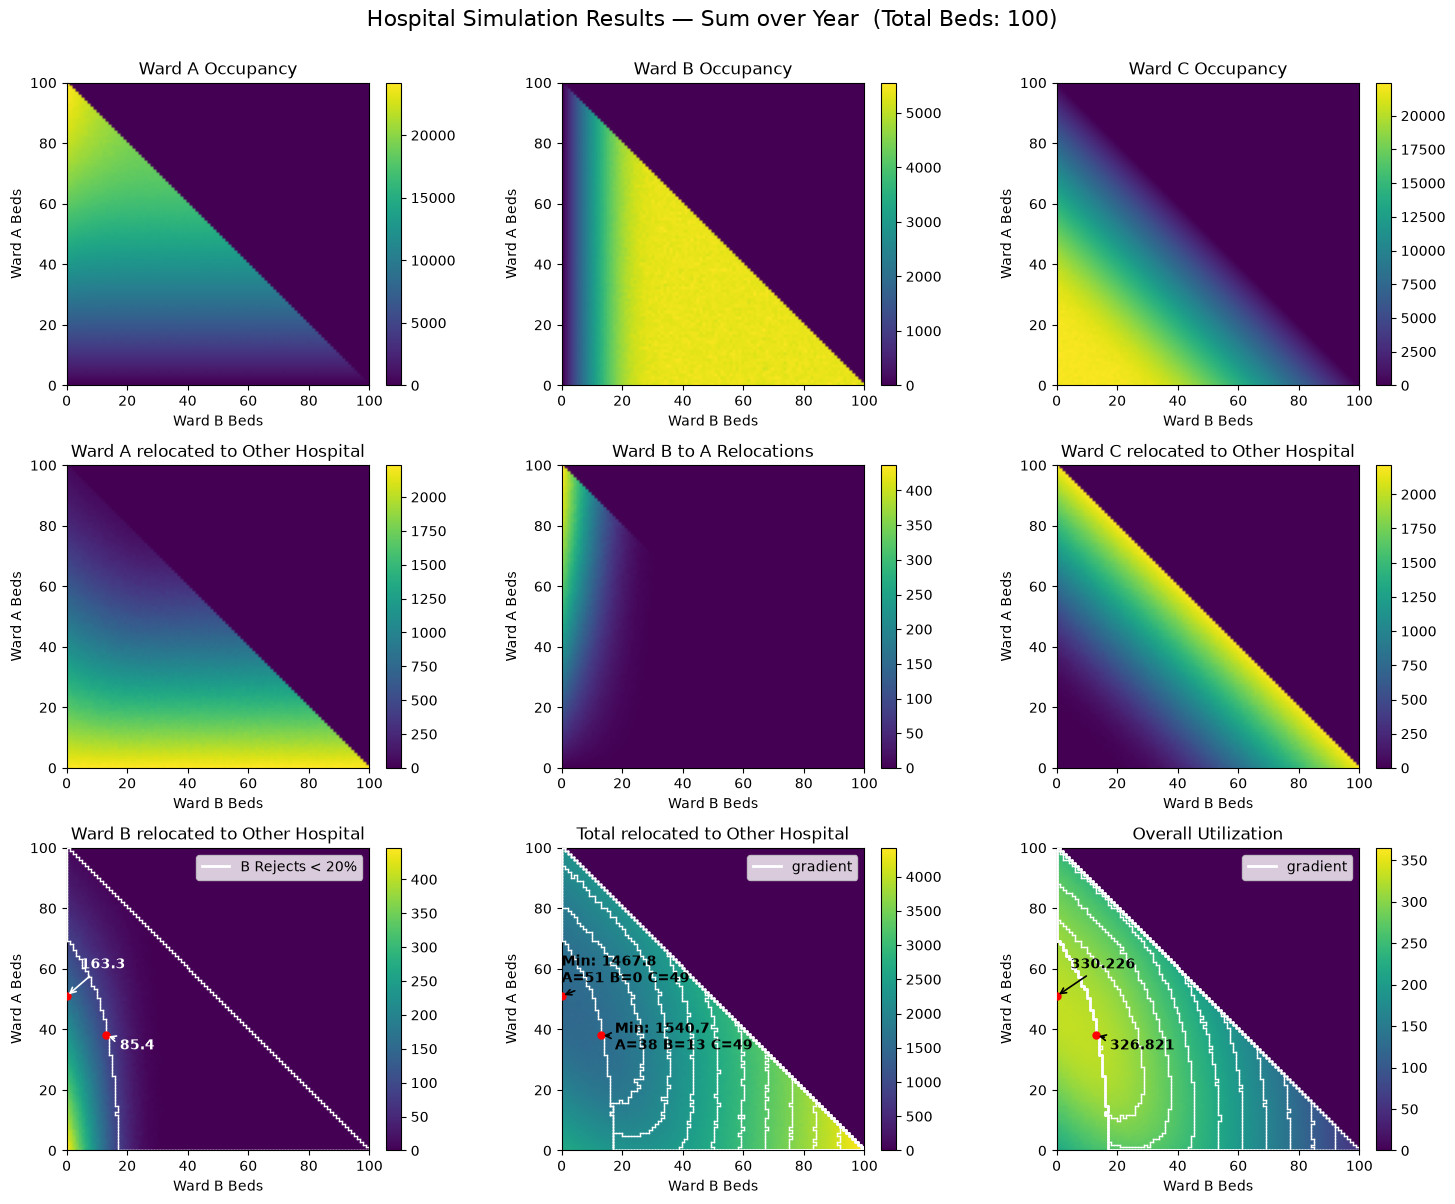

In [42]:
import pickle
num_beds = 100
with open(f"hospital_simulation_results_{num_beds}_{50}_samples.pkl", "rb") as f:
    configurations = pickle.load(f)
plot_configuration_results(configurations, num_beds=num_beds, statistic="sum")
f.close()
configurations = None